In [1]:
import pandas as pd


In [18]:
#creating table with custoerid, frequenc, monetary, first purchase date, last purchase date, lifespan
# ensure InvoiceDate is parsed as datetime to allow timedelta arithmetic
df = pd.read_csv("../data/processed/cleaned_retail_data.csv", parse_dates=["InvoiceDate"], infer_datetime_format=True)


C:\Users\sania\AppData\Local\Temp\ipykernel_10628\1915749923.py:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv("../data/processed/cleaned_retail_data.csv", parse_dates=["InvoiceDate"], infer_datetime_format=True)


In [22]:
snapshot_date = pd.to_datetime(df["InvoiceDate"]).max()

rfm = df.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "TotalPrice": "sum"
}).reset_index()

rfm.columns = ["Customer ID","Frequency", "Monetary"]


In [24]:
#adding invoice date to rfm table
first_purchase = df.groupby("Customer ID")["InvoiceDate"].min().reset_index()
first_purchase.columns = ["Customer ID", "First Purchase Date"]
rfm = rfm.merge(first_purchase, on="Customer ID", how="left")
last_purchase = df.groupby("Customer ID")["InvoiceDate"].max().reset_index()
last_purchase.columns = ["Customer ID", "Last Purchase Date"]
rfm = rfm.merge(last_purchase, on="Customer ID", how="left")
#adding lifespan column to rfm table
rfm["Lifespan"] = (rfm["Last Purchase Date"] - rfm["First Purchase Date"]).dt.days
rfm.head(10)

,Customer ID,Frequency,Monetary,First Purchase Date,Last Purchase Date,Lifespan
0,12346.0,12,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00,400
1,12347.0,8,4921.53,2010-10-31 14:20:00,2011-12-07 15:52:00,402
2,12348.0,5,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00,362
3,12349.0,4,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00,570
4,12350.0,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,0
5,12351.0,1,300.93,2010-11-29 15:23:00,2010-11-29 15:23:00,0
6,12352.0,10,2849.84,2010-11-12 10:20:00,2011-11-03 14:37:00,356
7,12353.0,2,406.76,2010-10-27 12:44:00,2011-05-19 17:47:00,204
8,12354.0,1,1079.40,2011-04-21 13:11:00,2011-04-21 13:11:00,0
9,12355.0,2,947.61,2010-05-21 11:59:00,2011-05-09 13:49:00,353


In [25]:
rfm.head(10)

,Customer ID,Frequency,Monetary,First Purchase Date,Last Purchase Date,Lifespan
0,12346.0,12,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00,400
1,12347.0,8,4921.53,2010-10-31 14:20:00,2011-12-07 15:52:00,402
2,12348.0,5,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00,362
3,12349.0,4,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00,570
4,12350.0,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,0
5,12351.0,1,300.93,2010-11-29 15:23:00,2010-11-29 15:23:00,0
6,12352.0,10,2849.84,2010-11-12 10:20:00,2011-11-03 14:37:00,356
7,12353.0,2,406.76,2010-10-27 12:44:00,2011-05-19 17:47:00,204
8,12354.0,1,1079.40,2011-04-21 13:11:00,2011-04-21 13:11:00,0
9,12355.0,2,947.61,2010-05-21 11:59:00,2011-05-09 13:49:00,353


In [26]:
rfm['Lifespan'].describe()

count    5878.000000
mean      273.022457
std       258.807591
min         0.000000
25%         0.000000
50%       220.500000
75%       511.000000
max       738.000000
Name: Lifespan, dtype: float64

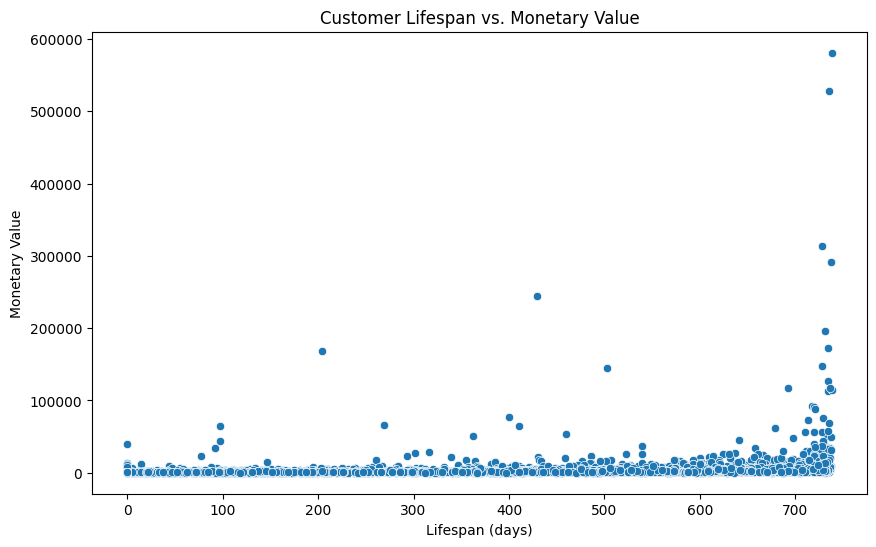

In [27]:
#relationship between monetary and lifespan
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Lifespan', y='Monetary')
plt.title('Customer Lifespan vs. Monetary Value')
plt.xlabel('Lifespan (days)')
plt.ylabel('Monetary Value')
plt.show()

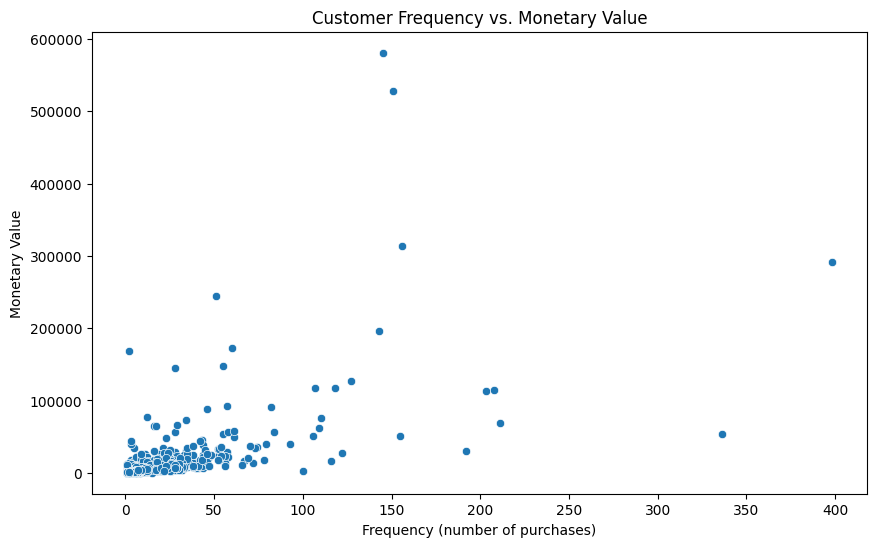

In [28]:
#relationship between frequency and monetary value
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary')
plt.title('Customer Frequency vs. Monetary Value')
plt.xlabel('Frequency (number of purchases)')
plt.ylabel('Monetary Value')
plt.show()


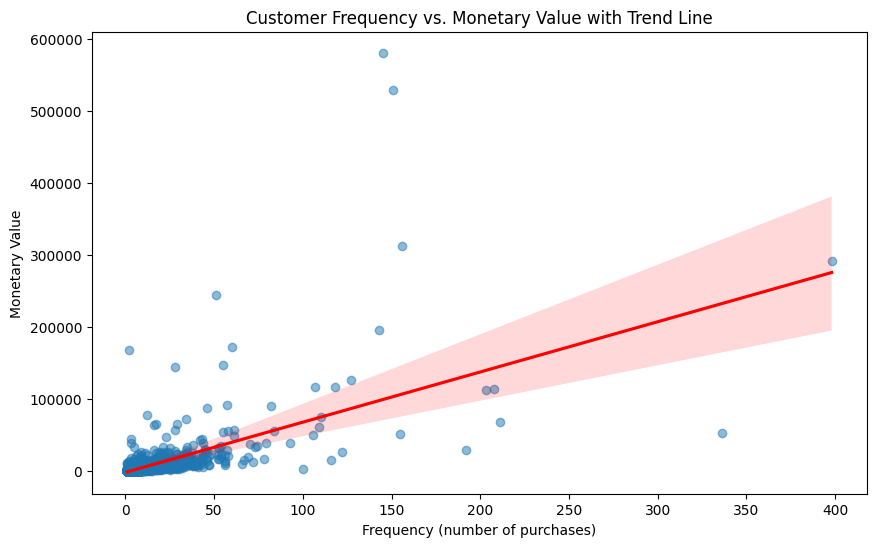

In [29]:

#curve between frequency and monetary value
plt.figure(figsize=(10, 6))
sns.regplot(data=rfm, x='Frequency', y='Monetary', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Customer Frequency vs. Monetary Value with Trend Line')
plt.xlabel('Frequency (number of purchases)')
plt.ylabel('Monetary Value')
plt.show()

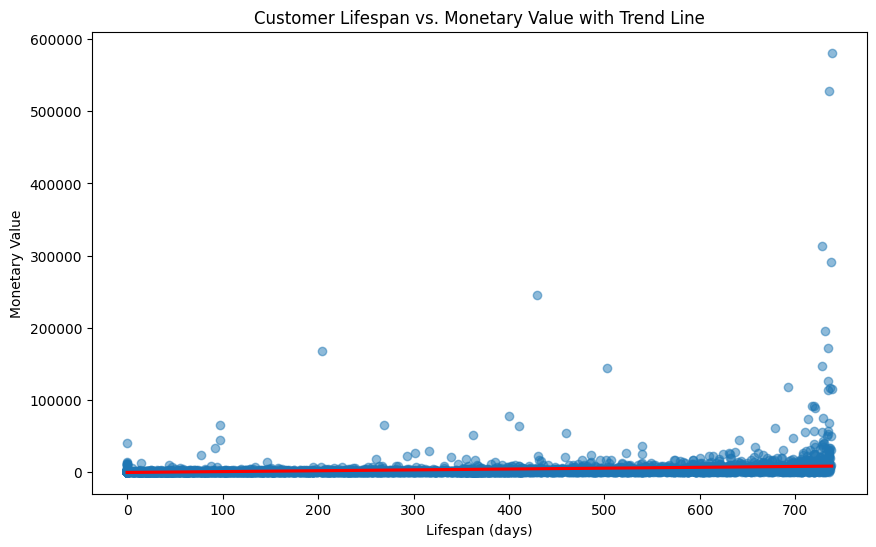

In [30]:
#curve between lifespan and monetary value
plt.figure(figsize=(10, 6))
sns.regplot(data=rfm, x='Lifespan', y='Monetary', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Customer Lifespan vs. Monetary Value with Trend Line')
plt.xlabel('Lifespan (days)')
plt.ylabel('Monetary Value')
plt.show()

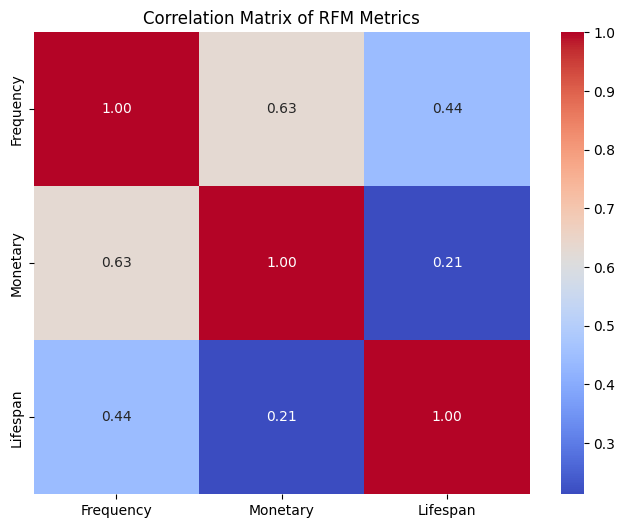

In [31]:
#correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(rfm[['Frequency', 'Monetary', 'Lifespan']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of RFM Metrics')
plt.show()

In [32]:
#scaling features for clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Frequency', 'Monetary', 'Lifespan']])



In [33]:
#clustering with KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head(10)

,Customer ID,Frequency,Monetary,First Purchase Date,Last Purchase Date,Lifespan,Cluster
0,12346.0,12,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00,400,1
1,12347.0,8,4921.53,2010-10-31 14:20:00,2011-12-07 15:52:00,402,1
2,12348.0,5,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00,362,1
3,12349.0,4,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00,570,1
4,12350.0,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,0,0
5,12351.0,1,300.93,2010-11-29 15:23:00,2010-11-29 15:23:00,0,0
6,12352.0,10,2849.84,2010-11-12 10:20:00,2011-11-03 14:37:00,356,1
7,12353.0,2,406.76,2010-10-27 12:44:00,2011-05-19 17:47:00,204,0
8,12354.0,1,1079.40,2011-04-21 13:11:00,2011-04-21 13:11:00,0,0
9,12355.0,2,947.61,2010-05-21 11:59:00,2011-05-09 13:49:00,353,1


In [34]:
#making table with cluster, average frequency, average monetary, average lifespan and count of customers in each cluster
cluster_summary = rfm.groupby('Cluster').agg({
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Lifespan': 'mean',
    'Customer ID': 'count'
}).reset_index()
cluster_summary.columns = ['Cluster', 'Avg Frequency', 'Avg Monetary', 'Avg Lifespan', 'Customer Count']
cluster_summary

,Cluster,Avg Frequency,Avg Monetary,Avg Lifespan,Customer Count
0,0,2.238744,772.068487,72.486967,3376
1,1,10.702213,4628.192074,542.595573,2485
2,2,165.647059,192190.808824,691.764706,17


In [36]:
#saving rfm table with cluster column to csv
rfm.to_csv("../data/processed/rfm_with_CLVclusters.csv", index=False)